<a href="https://colab.research.google.com/github/nayanajiju/INTERNSHIP/blob/main/Internship%20Day%205%20test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os
import pandas as pd

zip_path = "/content/archive (1) (1).zip" # Corrected path to the zip file
extract_path = "extracted_files"

# Extract ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all CSV files
dataframes = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_path = os.path.join(root, file)

            df = pd.read_csv(csv_path)
            dataframes.append(df)

print("Total CSV files loaded:", len(dataframes))

Total CSV files loaded: 2


In [2]:
# The previous cell already extracted the CSVs and loaded them into 'dataframes'.
# You can access individual dataframes from this list. For example, to see the first one:
df = dataframes[0] # Assuming you want to inspect the first dataframe in the list

# Display the first 5 rows
print(df.head())

   test_id                       description_x  \
0        0                        semtech corp   
1        1              vanguard mid cap index   
2        2         spdr gold trust gold shares   
3        3       vanguard total bond index adm   
4        4  oakmark international fund class i   

                      description_y  same_security  
0               semtech corporation            NaN  
1         vanguard midcap index - a            NaN  
2  spdr gold trust spdr gold shares            NaN  
3  vanguard total bond market index            NaN  
4        oakmark international cl i            NaN  


In [3]:
# Display original text
print("Original Text:")
print(df['description_x'].head()) # Changed 'text' to 'description_x'

# Convert text to lowercase
df['text_lower'] = df['description_x'].str.lower() # Changed 'text' to 'description_x'

# Display converted text
print("\nLowercase Text:")
print(df['text_lower'].head())

Original Text:
0                          semtech corp
1                vanguard mid cap index
2           spdr gold trust gold shares
3         vanguard total bond index adm
4    oakmark international fund class i
Name: description_x, dtype: object

Lowercase Text:
0                          semtech corp
1                vanguard mid cap index
2           spdr gold trust gold shares
3         vanguard total bond index adm
4    oakmark international fund class i
Name: text_lower, dtype: object


In [4]:
print(df.columns)

Index(['test_id', 'description_x', 'description_y', 'same_security',
       'text_lower'],
      dtype='object')


In [5]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab') # Download 'punkt_tab' resource

df['tokens'] = df['text_lower'].apply(lambda x: word_tokenize(str(x))) # Changed 'text' to 'text_lower'

# Display tokens for 5 samples
for i in range(5):
    print(f"Sample {i+1}:")
    print(df['tokens'].iloc[i])
    print()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Sample 1:
['semtech', 'corp']

Sample 2:
['vanguard', 'mid', 'cap', 'index']

Sample 3:
['spdr', 'gold', 'trust', 'gold', 'shares']

Sample 4:
['vanguard', 'total', 'bond', 'index', 'adm']

Sample 5:
['oakmark', 'international', 'fund', 'class', 'i']



[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [6]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords
df['text_no_stopwords'] = df['text_lower'].apply( # Changed 'text' to 'text_lower'
    lambda x: ' '.join(
        [word for word in str(x).split() if word.lower() not in stop_words]
    )
)

# Show before and after for 5 samples
for i in range(5):
    print(f"Sample {i+1}")
    print("Before :", df['text_lower'].iloc[i]) # Changed 'text' to 'text_lower'
    print("After  :", df['text_no_stopwords'].iloc[i])
    print()

[nltk_data] Downloading package stopwords to /root/nltk_data...


Sample 1
Before : semtech corp
After  : semtech corp

Sample 2
Before : vanguard mid cap index
After  : vanguard mid cap index

Sample 3
Before : spdr gold trust gold shares
After  : spdr gold trust gold shares

Sample 4
Before : vanguard total bond index adm
After  : vanguard total bond index adm

Sample 5
Before : oakmark international fund class i
After  : oakmark international fund class



[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
print(df.columns)


Index(['test_id', 'description_x', 'description_y', 'same_security',
       'text_lower', 'tokens', 'text_no_stopwords'],
      dtype='object')


In [8]:
import nltk
from nltk.stem import PorterStemmer

nltk.download('punkt')

ps = PorterStemmer()

# Apply stemming
df['stemmed_text'] = df['text_no_stopwords'].apply( # Changed 'text' to 'text_no_stopwords'
    lambda x: ' '.join([ps.stem(word) for word in str(x).split()])
)

# Display 10 samples
for i in range(10):
    print(f"Sample {i+1}")
    print("Original :", df['text_no_stopwords'].iloc[i]) # Changed 'text' to 'text_no_stopwords'
    print("Stemmed  :", df['stemmed_text'].iloc[i])
    print()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Sample 1
Original : semtech corp
Stemmed  : semtech corp

Sample 2
Original : vanguard mid cap index
Stemmed  : vanguard mid cap index

Sample 3
Original : spdr gold trust gold shares
Stemmed  : spdr gold trust gold share

Sample 4
Original : vanguard total bond index adm
Stemmed  : vanguard total bond index adm

Sample 5
Original : oakmark international fund class
Stemmed  : oakmark intern fund class

Sample 6
Original : pfizer inc div: 1.200
Stemmed  : pfizer inc div: 1.200

Sample 7
Original : spartan global ex us index fid adv cl
Stemmed  : spartan global ex us index fid adv cl

Sample 8
Original : vanguard total bond market idx-adm
Stemmed  : vanguard total bond market idx-adm

Sample 9
Original : banco latinoamericano de exportacio class e com stk npv
Stemmed  : banco latinoamericano de exportacio class e com stk npv

Sample 10
Original : baidu inc fadr 1 adr reps 0.1 ord shs
Stemmed  : baidu inc fadr 1 adr rep 0.1 ord sh



In [9]:

import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

df['stemmed_text'] = df['text_no_stopwords'].apply(
    lambda x: ' '.join([ps.stem(word) for word in str(x).split()])
)

df['lemmatized_text'] = df['text_no_stopwords'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in str(x).split()])
)

for i in range(10):
    print(f"Sample {i+1}")
    print("Original   :", df['text_no_stopwords'].iloc[i])
    print("Stemmed    :", df['stemmed_text'].iloc[i])
    print("Lemmatized :", df['lemmatized_text'].iloc[i])
    print()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Sample 1
Original   : semtech corp
Stemmed    : semtech corp
Lemmatized : semtech corp

Sample 2
Original   : vanguard mid cap index
Stemmed    : vanguard mid cap index
Lemmatized : vanguard mid cap index

Sample 3
Original   : spdr gold trust gold shares
Stemmed    : spdr gold trust gold share
Lemmatized : spdr gold trust gold share

Sample 4
Original   : vanguard total bond index adm
Stemmed    : vanguard total bond index adm
Lemmatized : vanguard total bond index adm

Sample 5
Original   : oakmark international fund class
Stemmed    : oakmark intern fund class
Lemmatized : oakmark international fund class

Sample 6
Original   : pfizer inc div: 1.200
Stemmed    : pfizer inc div: 1.200
Lemmatized : pfizer inc div: 1.200

Sample 7
Original   : spartan global ex us index fid adv cl
Stemmed    : spartan global ex us index fid adv cl
Lemmatized : spartan global ex u index fid adv cl

Sample 8
Original   : vanguard total bond market idx-adm
Stemmed    : vanguard total bond market idx-adm
L

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Create BoW model
vectorizer = CountVectorizer()

# Fit and transform the text data
X = vectorizer.fit_transform(df['text_no_stopwords'].astype(str))

# Vocabulary
print("Vocabulary:")
print(vectorizer.vocabulary_)

# Feature Names
print("\nFeature Names:")
print(vectorizer.get_feature_names_out())

# BoW Matrix
print("\nBoW Matrix:")
print(X.toarray())

# Shape of Matrix
print("\nShape:")
print(X.shape)

Vocabulary:
{'semtech': 524, 'corp': 167, 'vanguard': 644, 'mid': 404, 'cap': 129, 'index': 318, 'spdr': 555, 'gold': 276, 'trust': 612, 'shares': 529, 'total': 599, 'bond': 116, 'adm': 43, 'oakmark': 440, 'international': 334, 'fund': 263, 'class': 146, 'pfizer': 467, 'inc': 313, 'div': 197, '200': 13, 'spartan': 554, 'global': 274, 'ex': 230, 'us': 623, 'fid': 244, 'adv': 51, 'cl': 144, 'market': 389, 'idx': 311, 'banco': 93, 'latinoamericano': 366, 'de': 178, 'exportacio': 234, 'com': 156, 'stk': 568, 'npv': 434, 'baidu': 91, 'fadr': 240, 'adr': 49, 'reps': 499, 'ord': 452, 'shs': 536, 'whole': 666, 'foods': 256, 'walgreens': 658, 'boots': 118, 'alliance': 64, 'diageo': 193, 'plc': 471, 'new': 430, 'gb': 267, 'spon': 556, 'guggenheim': 289, 'bulletshares': 125, '2016': 15, 'small': 544, 'emerging': 214, 'markets': 390, '500': 33, 'etf': 224, 'iv': 352, 'tegna': 585, 'deere': 179, 'company': 160, 'jpmorgan': 359, 'chase': 137, 'co': 151, '760': 36, 'american': 69, 'funds': 264, 'euro

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF model
vectorizer = TfidfVectorizer()

# Fit and transform the text data
X_tfidf = vectorizer.fit_transform(df['text_no_stopwords'].astype(str))

# Vocabulary
print("Vocabulary:")
print(vectorizer.vocabulary_)

# Feature Names
print("\nFeature Names:")
print(vectorizer.get_feature_names_out())

# TF-IDF Matrix
print("\nTF-IDF Matrix:")
print(X_tfidf.toarray())

# Shape of Matrix
print("\nShape:")
print(X_tfidf.shape)

Vocabulary:
{'semtech': 524, 'corp': 167, 'vanguard': 644, 'mid': 404, 'cap': 129, 'index': 318, 'spdr': 555, 'gold': 276, 'trust': 612, 'shares': 529, 'total': 599, 'bond': 116, 'adm': 43, 'oakmark': 440, 'international': 334, 'fund': 263, 'class': 146, 'pfizer': 467, 'inc': 313, 'div': 197, '200': 13, 'spartan': 554, 'global': 274, 'ex': 230, 'us': 623, 'fid': 244, 'adv': 51, 'cl': 144, 'market': 389, 'idx': 311, 'banco': 93, 'latinoamericano': 366, 'de': 178, 'exportacio': 234, 'com': 156, 'stk': 568, 'npv': 434, 'baidu': 91, 'fadr': 240, 'adr': 49, 'reps': 499, 'ord': 452, 'shs': 536, 'whole': 666, 'foods': 256, 'walgreens': 658, 'boots': 118, 'alliance': 64, 'diageo': 193, 'plc': 471, 'new': 430, 'gb': 267, 'spon': 556, 'guggenheim': 289, 'bulletshares': 125, '2016': 15, 'small': 544, 'emerging': 214, 'markets': 390, '500': 33, 'etf': 224, 'iv': 352, 'tegna': 585, 'deere': 179, 'company': 160, 'jpmorgan': 359, 'chase': 137, 'co': 151, '760': 36, 'american': 69, 'funds': 264, 'euro

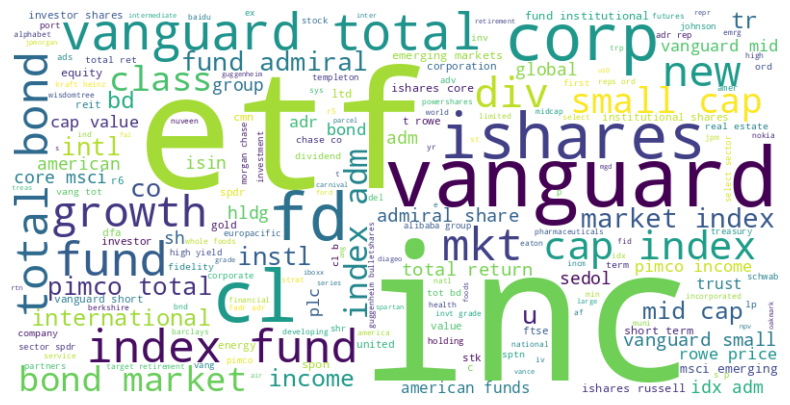

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text into one string
text = " ".join(df['text_no_stopwords'].astype(str))

# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()